# 04 · Modeling
### Dirección de Productos de Crédito — Minería de Datos UNAM

Entrenamiento, evaluación y selección del mejor modelo para cada pregunta de negocio.

---

### Dos preguntas, dos modelos

| Modelo | Pregunta | Target | Dataset |
|---|---|---|---|
| M1 — Aprobación | ¿Se aprobará esta solicitud? | `TARGET_APROBADO` (0/1) | `features_modelo_aprobacion.csv` |
| M2 — Producto | ¿Qué producto corresponde? | `TARGET_PRODUCTO` (0/1/2) | `features_modelo_producto.csv` |

### Algoritmos evaluados

| Algoritmo | Fortaleza | Limitación |
|---|---|---|
| Regresión Logística | Interpretable, baseline sólido | Asume linealidad |
| Random Forest | Robusto, feature importances | Más lento |
| Gradient Boosting | Mejor rendimiento general | Menos interpretable |

### Métricas calculadas
Accuracy · Precision · Recall · **F1 macro** · ROC-AUC · **Cohen's Kappa** · **Matriz de confusión**

### Nota sobre el dataset
Este dataset es **sintético** (creado para fines académicos). En datos sintéticos las reglas
de generación son deterministas — es esperable que los modelos alcancen métricas muy altas
porque esencialmente re-descubren la fórmula que generó los datos.
En un dataset bancario real existiría ruido, casos límite y relaciones no perfectas.


## 0 · Imports y configuración

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "imbalanced-learn", "--break-system-packages", "-q"],
               capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, cohen_kappa_score,
                                      confusion_matrix, ConfusionMatrixDisplay,
                                      classification_report)
from sklearn.preprocessing    import label_binarize
from imblearn.over_sampling   import SMOTE

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa", "axes.spines.top": False,
    "axes.spines.right": False, "font.family": "sans-serif",
    "axes.titlesize": 12, "axes.labelsize": 10,
})
RED, BLUE, GREEN, ORANGE = "#c0392b", "#2980b9", "#27ae60", "#e67e22"
SQ_G = "\033[32m■\033[0m"
SQ_R = "\033[31m■\033[0m"
SQ_B = "\033[34m■\033[0m"
SQ_Y = "\033[33m■\033[0m"
SEED = 42
etqs = {0: "CLASICA", 1: "TARJETA_ORO", 2: "CREDITO_AUTO"}

print(f"{SQ_G} Librerias cargadas")


■ Librerias cargadas


## 1 · Carga de datos

In [2]:
df_m1 = pd.read_csv("../data/processed/features_modelo_aprobacion.csv")
df_m2 = pd.read_csv("../data/processed/features_modelo_producto.csv")

print(f"  {SQ_B}  M1 — Aprobacion : {df_m1.shape[0]:,} filas x {df_m1.shape[1]} columnas")
print(f"  {SQ_B}  M2 — Producto   : {df_m2.shape[0]:,} filas x {df_m2.shape[1]} columnas")
print()

print("Distribucion de targets:")
print()
print("  TARGET_APROBADO (M1):")
for v, c in df_m1["TARGET_APROBADO"].value_counts().sort_index().items():
    etq = "Aprobado" if v == 1 else "Rechazado"
    pct = c / len(df_m1) * 100
    bar = chr(9608) * int(pct / 2)
    print(f"    {v} ({etq:<10})  {c:>5,}  ({pct:.1f}%)  {bar}")

print()
print("  TARGET_PRODUCTO (M2):")
for v, c in df_m2["TARGET_PRODUCTO"].value_counts().sort_index().items():
    pct = c / len(df_m2) * 100
    bar = chr(9608) * int(pct / 3)
    print(f"    {int(v)} ({etqs[int(v)]:<14})  {c:>5,}  ({pct:.1f}%)  {bar}")

# Identificar columnas string en M2 para excluirlas
cols_str_m2 = df_m2.select_dtypes(include="object").columns.tolist()
print()
if cols_str_m2:
    print(f"  {SQ_Y}  Columnas string en M2 (se excluyen del modelo, ya tienen version ordinal):")
    for c in cols_str_m2:
        print(f"       {c}")


  ■  M1 — Aprobacion : 4,349 filas x 33 columnas
  ■  M2 — Producto   : 1,637 filas x 40 columnas

Distribucion de targets:

  TARGET_APROBADO (M1):
    0 (Rechazado )  2,712  (62.4%)  ███████████████████████████████
    1 (Aprobado  )  1,637  (37.6%)  ██████████████████

  TARGET_PRODUCTO (M2):
    0 (CLASICA       )  1,573  (96.1%)  ████████████████████████████████
    1 (TARJETA_ORO   )     24  (1.5%)  
    2 (CREDITO_AUTO  )     40  (2.4%)  

  ■  Columnas string en M2 (se excluyen del modelo, ya tienen version ordinal):
       MESES_VENCIDOS


---
## Función central de métricas

In [3]:
def evaluar_modelo(nombre, modelo, X_test, y_test, multi=False, ax_cm=None):
    y_pred = modelo.predict(X_test)
    avg    = "macro" if multi else "binary"

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average=avg, zero_division=0)
    rec   = recall_score(y_test, y_pred, average=avg, zero_division=0)
    f1    = f1_score(y_test, y_pred, average=avg, zero_division=0)
    kappa = cohen_kappa_score(y_test, y_pred)

    if multi:
        clases = sorted(y_test.unique())
        y_bin  = label_binarize(y_test, classes=clases)
        y_prob = modelo.predict_proba(X_test)
        auc    = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    else:
        y_prob = modelo.predict_proba(X_test)[:, 1]
        auc    = roc_auc_score(y_test, y_prob)

    if ax_cm is not None:
        cm   = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
        ax_cm.set_title(nombre, fontweight="bold", fontsize=10)

    return {"Modelo": nombre, "Accuracy": round(acc,4), "Precision": round(prec,4),
            "Recall": round(rec,4), "F1_macro": round(f1,4),
            "ROC_AUC": round(auc,4), "Kappa": round(kappa,4)}

def imprimir_metricas(res):
    for k in ["Accuracy","Precision","Recall","F1_macro","ROC_AUC","Kappa"]:
        sq = SQ_G if res[k] >= 0.8 else (SQ_Y if res[k] >= 0.6 else SQ_R)
        print(f"    {sq}  {k:<12}: {res[k]:.4f}")

print(f"{SQ_G} Funcion de metricas lista")


■ Funcion de metricas lista


---
# M1 · Modelo de Aprobación

**Objetivo:** predecir si una solicitud será aprobada (1) o rechazada (0).

**Desbalance:** 62.4% rechazadas / 37.6% aprobadas → `class_weight='balanced'`.


## M1.1 · Train / Test split

In [4]:
TARGET_M1       = "TARGET_APROBADO"
FEATURES_M1_ALL = [c for c in df_m1.columns if c != TARGET_M1]
# LR excluye SUCURSAL (200 categorias sin codificar, no linealizable)
FEATURES_M1_LR  = [c for c in FEATURES_M1_ALL if c != "SUCURSAL"]

X_m1 = df_m1[FEATURES_M1_ALL]
y_m1 = df_m1[TARGET_M1]

X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(
    X_m1, y_m1, test_size=0.2, random_state=SEED, stratify=y_m1
)

print(f"  {SQ_B}  Train : {X_train_m1.shape[0]:,}  |  Test : {X_test_m1.shape[0]:,}  (80/20 estratificado)")
print()
for split, y in [("Train", y_train_m1), ("Test", y_test_m1)]:
    aprobados = (y == 1).sum()
    print(f"  {split}: Rechazados {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)  "
          f"Aprobados {aprobados:,} ({(y==1).mean()*100:.1f}%)")


  ■  Train : 3,479  |  Test : 870  (80/20 estratificado)

  Train: Rechazados 2,169 (62.3%)  Aprobados 1,310 (37.7%)
  Test: Rechazados 543 (62.4%)  Aprobados 327 (37.6%)


## M1.2 · Regresión Logística (baseline)

=== M1 — Regresion Logistica ===



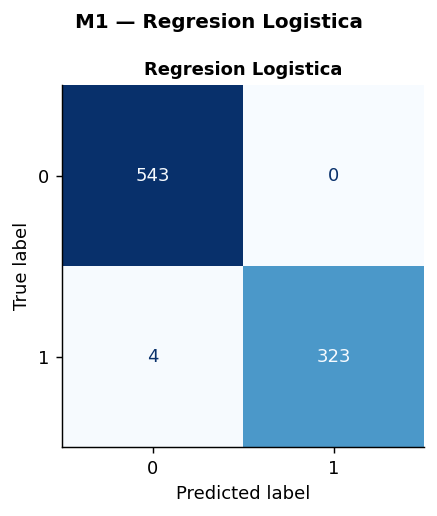

    ■  Accuracy    : 0.9954
    ■  Precision   : 1.0000
    ■  Recall      : 0.9878
    ■  F1_macro    : 0.9938
    ■  ROC_AUC     : 1.0000
    ■  Kappa       : 0.9902

              precision    recall  f1-score   support

   Rechazado       0.99      1.00      1.00       543
    Aprobado       1.00      0.99      0.99       327

    accuracy                           1.00       870
   macro avg       1.00      0.99      1.00       870
weighted avg       1.00      1.00      1.00       870



In [5]:
print("=== M1 — Regresion Logistica ===")
print()

lr_m1 = LogisticRegression(class_weight="balanced", max_iter=1000,
                            random_state=SEED, solver="lbfgs")
lr_m1.fit(X_train_m1[FEATURES_M1_LR], y_train_m1)

fig, ax = plt.subplots(figsize=(4, 4))
res_lr_m1 = evaluar_modelo("Regresion Logistica", lr_m1,
                            X_test_m1[FEATURES_M1_LR], y_test_m1, ax_cm=ax)
plt.suptitle("M1 — Regresion Logistica", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/04_cm_m1_lr.png", bbox_inches="tight")
plt.show()

imprimir_metricas(res_lr_m1)
print()
print(classification_report(y_test_m1, lr_m1.predict(X_test_m1[FEATURES_M1_LR]),
                             target_names=["Rechazado","Aprobado"]))


## M1.3 · Random Forest

=== M1 — Random Forest ===



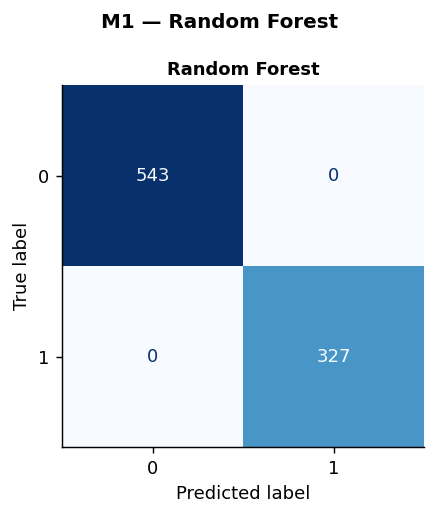

    ■  Accuracy    : 1.0000
    ■  Precision   : 1.0000
    ■  Recall      : 1.0000
    ■  F1_macro    : 1.0000
    ■  ROC_AUC     : 1.0000
    ■  Kappa       : 1.0000

              precision    recall  f1-score   support

   Rechazado       1.00      1.00      1.00       543
    Aprobado       1.00      1.00      1.00       327

    accuracy                           1.00       870
   macro avg       1.00      1.00      1.00       870
weighted avg       1.00      1.00      1.00       870



In [6]:
print("=== M1 — Random Forest ===")
print()

rf_m1 = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                random_state=SEED, n_jobs=-1)
rf_m1.fit(X_train_m1, y_train_m1)

fig, ax = plt.subplots(figsize=(4, 4))
res_rf_m1 = evaluar_modelo("Random Forest", rf_m1, X_test_m1, y_test_m1, ax_cm=ax)
plt.suptitle("M1 — Random Forest", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/04_cm_m1_rf.png", bbox_inches="tight")
plt.show()

imprimir_metricas(res_rf_m1)
print()
print(classification_report(y_test_m1, rf_m1.predict(X_test_m1),
                             target_names=["Rechazado","Aprobado"]))


## M1.4 · Gradient Boosting

=== M1 — Gradient Boosting ===



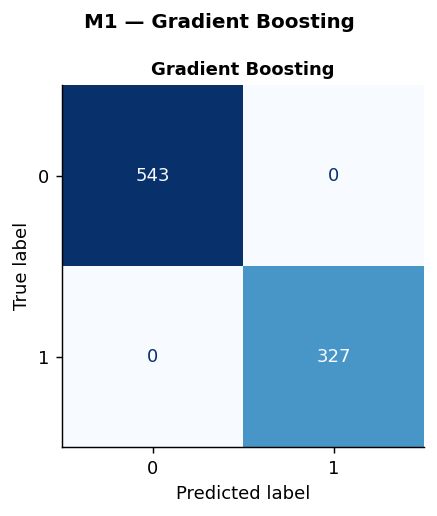

    ■  Accuracy    : 1.0000
    ■  Precision   : 1.0000
    ■  Recall      : 1.0000
    ■  F1_macro    : 1.0000
    ■  ROC_AUC     : 1.0000
    ■  Kappa       : 1.0000

              precision    recall  f1-score   support

   Rechazado       1.00      1.00      1.00       543
    Aprobado       1.00      1.00      1.00       327

    accuracy                           1.00       870
   macro avg       1.00      1.00      1.00       870
weighted avg       1.00      1.00      1.00       870



In [7]:
print("=== M1 — Gradient Boosting ===")
print()

gb_m1 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                     max_depth=4, random_state=SEED)
sw = np.where(y_train_m1 == 0,
              len(y_train_m1) / (2 * (y_train_m1 == 0).sum()),
              len(y_train_m1) / (2 * (y_train_m1 == 1).sum()))
gb_m1.fit(X_train_m1, y_train_m1, sample_weight=sw)

fig, ax = plt.subplots(figsize=(4, 4))
res_gb_m1 = evaluar_modelo("Gradient Boosting", gb_m1, X_test_m1, y_test_m1, ax_cm=ax)
plt.suptitle("M1 — Gradient Boosting", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/04_cm_m1_gb.png", bbox_inches="tight")
plt.show()

imprimir_metricas(res_gb_m1)
print()
print(classification_report(y_test_m1, gb_m1.predict(X_test_m1),
                             target_names=["Rechazado","Aprobado"]))


## M1.5 · Comparación, validación cruzada y selección

In [8]:
resultados_m1 = pd.DataFrame([res_lr_m1, res_rf_m1, res_gb_m1]).set_index("Modelo")

print("=== COMPARACION M1 — Aprobacion ===")
print()
print(resultados_m1.to_string())
print()

mejor_m1_nombre = resultados_m1["F1_macro"].idxmax()
mejor_m1        = {"Regresion Logistica": lr_m1,
                   "Random Forest": rf_m1,
                   "Gradient Boosting": gb_m1}[mejor_m1_nombre]
X_mejor_m1      = X_m1[FEATURES_M1_LR] if mejor_m1_nombre == "Regresion Logistica" else X_m1

print(f"  {SQ_G}  Mejor modelo : {mejor_m1_nombre}")
print(f"  {SQ_G}  F1 macro     : {resultados_m1.loc[mejor_m1_nombre,'F1_macro']:.4f}")
print(f"  {SQ_G}  Kappa        : {resultados_m1.loc[mejor_m1_nombre,'Kappa']:.4f}")
print()

# ── Validacion cruzada (sanity check) ────────────────────────────────────────
print("  Validacion cruzada 5-fold (confirma que no es sobreajuste al split):")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_validate(mejor_m1, X_mejor_m1, y_m1, cv=cv,
                            scoring=["accuracy","f1_macro","roc_auc"],
                            n_jobs=-1)

for metrica, vals in [("Accuracy", cv_scores["test_accuracy"]),
                       ("F1 macro", cv_scores["test_f1_macro"]),
                       ("ROC-AUC",  cv_scores["test_roc_auc"])]:
    print(f"    {metrica:<12}  folds: {[round(v,4) for v in vals]}")
    print(f"               media={vals.mean():.4f}  std={vals.std():.4f}")

print()
print(f"  {SQ_Y}  Nota: metricas muy altas son esperables en un dataset sintetico.")
print(f"  {SQ_Y}  Los scores fueron generados deterministicamente al crear los datos.")
print(f"  {SQ_Y}  La std baja en validacion cruzada confirma que el modelo es estable,")
print(f"  {SQ_Y}  no un artefacto del split especifico.")


=== COMPARACION M1 — Aprobacion ===

                     Accuracy  Precision  Recall  F1_macro  ROC_AUC   Kappa
Modelo                                                                     
Regresion Logistica    0.9954        1.0  0.9878    0.9938      1.0  0.9902
Random Forest          1.0000        1.0  1.0000    1.0000      1.0  1.0000
Gradient Boosting      1.0000        1.0  1.0000    1.0000      1.0  1.0000

  ■  Mejor modelo : Random Forest
  ■  F1 macro     : 1.0000
  ■  Kappa        : 1.0000

  Validacion cruzada 5-fold (confirma que no es sobreajuste al split):
    Accuracy      folds: [1.0, 1.0, 1.0, 1.0, 1.0]
               media=1.0000  std=0.0000
    F1 macro      folds: [1.0, 1.0, 1.0, 1.0, 1.0]
               media=1.0000  std=0.0000
    ROC-AUC       folds: [1.0, 1.0, 1.0, 1.0, 1.0]
               media=1.0000  std=0.0000

  ■  Nota: metricas muy altas son esperables en un dataset sintetico.
  ■  Los scores fueron generados deterministicamente al crear los datos.
  ■  

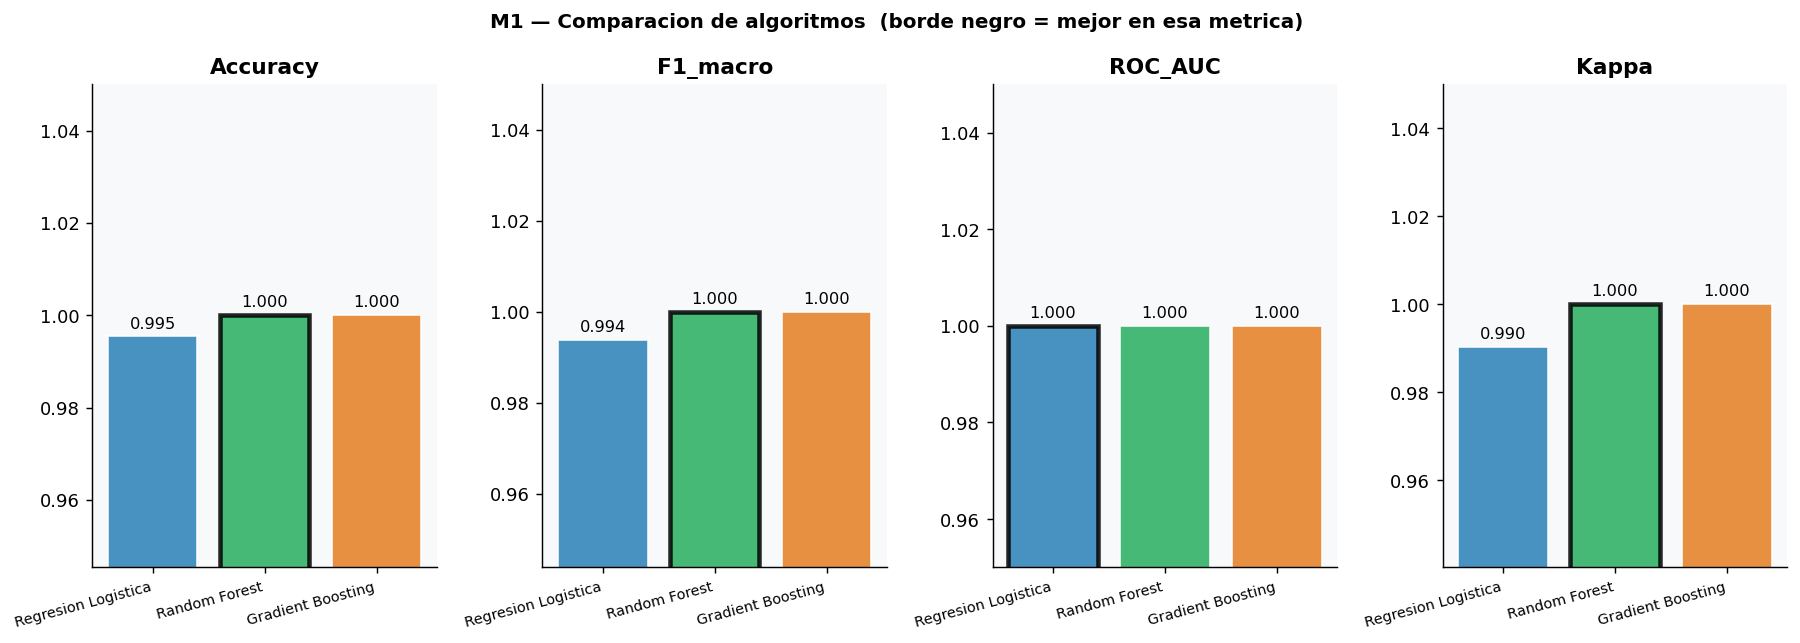

In [9]:
metricas_plot = ["Accuracy","F1_macro","ROC_AUC","Kappa"]
fig, axes = plt.subplots(1, len(metricas_plot), figsize=(14, 5))
colores   = [BLUE, GREEN, ORANGE]

for ax, met in zip(axes, metricas_plot):
    vals = resultados_m1[met].values
    bars = ax.bar(resultados_m1.index, vals, color=colores, alpha=0.85, edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=3, fontsize=9)
    ax.set_ylim(max(0, min(vals) - 0.05), 1.05)
    ax.set_title(met, fontweight="bold")
    ax.set_xticklabels(resultados_m1.index, rotation=15, ha="right", fontsize=8)
    mejor_idx = list(resultados_m1.index).index(resultados_m1[met].idxmax())
    bars[mejor_idx].set_edgecolor("black")
    bars[mejor_idx].set_linewidth(2.5)

plt.suptitle("M1 — Comparacion de algoritmos  (borde negro = mejor en esa metrica)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/04_comparacion_m1.png", bbox_inches="tight")
plt.show()


## M1.6 · Feature importance

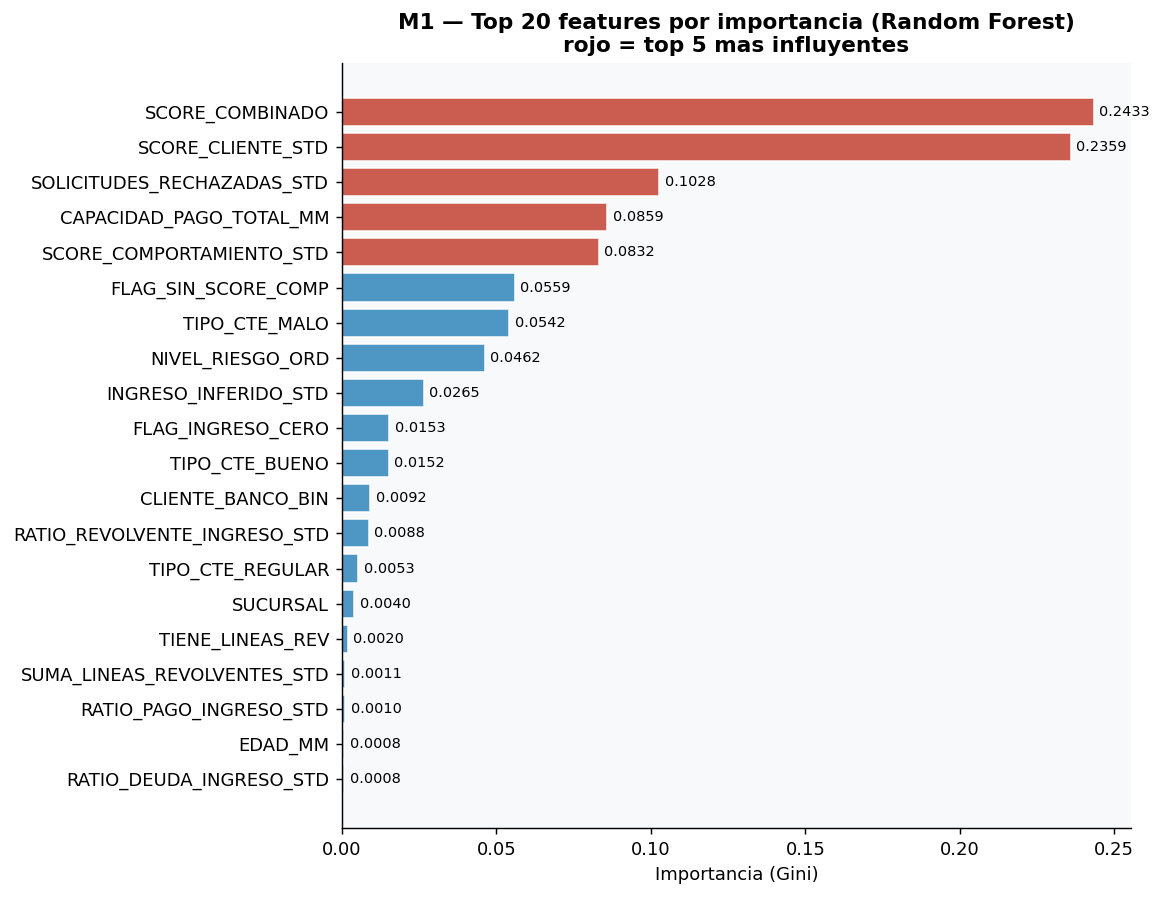

Top 10 features M1:
  SCORE_COMBINADO                            0.2433  ████████████████████████████████████████████████████████████
  SCORE_CLIENTE_STD                          0.2359  ██████████████████████████████████████████████████████████
  SOLICITUDES_RECHAZADAS_STD                 0.1028  █████████████████████████
  CAPACIDAD_PAGO_TOTAL_MM                    0.0859  █████████████████████
  SCORE_COMPORTAMIENTO_STD                   0.0832  ████████████████████
  FLAG_SIN_SCORE_COMP                        0.0559  █████████████
  TIPO_CTE_MALO                              0.0542  █████████████
  NIVEL_RIESGO_ORD                           0.0462  ███████████
  INGRESO_INFERIDO_STD                       0.0265  ██████
  FLAG_INGRESO_CERO                          0.0153  ███

  ■  Las 2 variables mas importantes acumulan 47.9% de la importancia total.
  ■  En un dataset sintetico, el score fue probablemente la regla de aprobacion.
  ■  El modelo re-descubre esa regla — por eso las 

In [10]:
imp_m1 = pd.Series(rf_m1.feature_importances_, index=FEATURES_M1_ALL)
imp_m1 = imp_m1.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [RED if i < 5 else BLUE for i in range(len(imp_m1))]
bars = ax.barh(imp_m1.index[::-1], imp_m1.values[::-1],
               color=colors[::-1], alpha=0.82, edgecolor="white")
ax.bar_label(bars, labels=[f"{v:.4f}" for v in imp_m1.values[::-1]],
             padding=3, fontsize=8)
ax.set_title("M1 — Top 20 features por importancia (Random Forest)\n"
             "rojo = top 5 mas influyentes", fontweight="bold")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.savefig("../reports/figures/04_feature_importance_m1.png", bbox_inches="tight")
plt.show()

print("Top 10 features M1:")
for feat, imp in imp_m1.head(10).items():
    bar = chr(9608) * int(imp * 250)
    print(f"  {feat:<42} {imp:.4f}  {bar}")
print()

# Analisis de por que las metricas son tan altas
top2_imp = imp_m1.head(2).sum()
print(f"  {SQ_Y}  Las 2 variables mas importantes acumulan {top2_imp:.1%} de la importancia total.")
print(f"  {SQ_Y}  En un dataset sintetico, el score fue probablemente la regla de aprobacion.")
print(f"  {SQ_Y}  El modelo re-descubre esa regla — por eso las metricas son casi perfectas.")


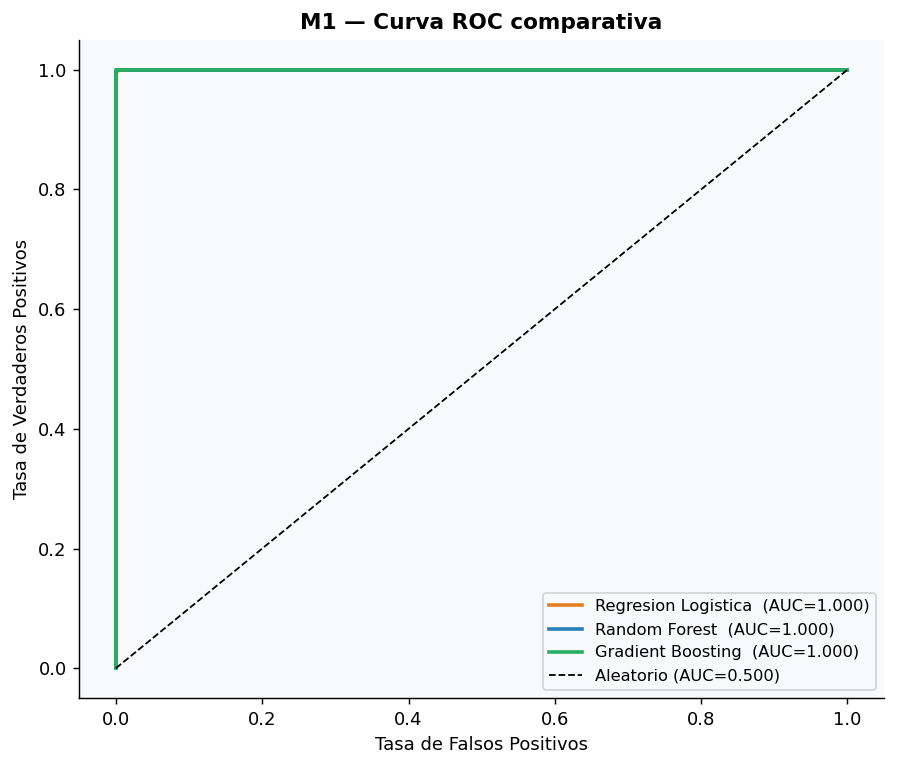

In [11]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
modelos_roc = [("Regresion Logistica", lr_m1, X_test_m1[FEATURES_M1_LR]),
               ("Random Forest",       rf_m1, X_test_m1),
               ("Gradient Boosting",   gb_m1, X_test_m1)]
colores_roc = [ORANGE, BLUE, GREEN]

for (nombre, modelo, X_te), color in zip(modelos_roc, colores_roc):
    y_prob = modelo.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_m1, y_prob)
    auc = roc_auc_score(y_test_m1, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{nombre}  (AUC={auc:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Aleatorio (AUC=0.500)")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("M1 — Curva ROC comparativa", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/04_roc_m1.png", bbox_inches="tight")
plt.show()


---
# M2 · Modelo de Producto

**Objetivo:** dado un cliente aprobado, predecir qué producto se le asignará.

**Desafío critico — desbalance extremo:**

| Clase | Registros | % |
|---|---|---|
| CLASICA (0) | 1,573 | 96.1% |
| TARJETA_ORO (1) | 24 | 1.5% |
| CREDITO_AUTO (2) | 40 | 2.4% |

Un modelo que prediga siempre CLASICA tendría 96% de accuracy pero sería inútil.  
Se usa SMOTE para balancear y se evalúa con **F1 macro** que penaliza ignorar clases minoritarias.


## M2.1 · Preparación y SMOTE

In [12]:
print("=== M2 — Preparacion y SMOTE ===")
print()

TARGET_M2  = "TARGET_PRODUCTO"

# Excluir columnas string — MESES_VENCIDOS queda como string en el CSV
# su version numerica MESES_VENCIDOS_ORD ya esta incluida
cols_excluir_m2 = df_m2.select_dtypes(include="object").columns.tolist()
FEATURES_M2 = [c for c in df_m2.columns if c != TARGET_M2 and c not in cols_excluir_m2]

if cols_excluir_m2:
    print(f"  {SQ_Y}  Columnas string excluidas (ya tienen version ordinal numerica):")
    for c in cols_excluir_m2:
        print(f"       {c}")
    print()

X_m2 = df_m2[FEATURES_M2].astype(float)
y_m2 = df_m2[TARGET_M2].astype(int)

X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(
    X_m2, y_m2, test_size=0.2, random_state=SEED, stratify=y_m2
)

print(f"  {SQ_B}  Train original : {X_train_m2.shape[0]:,}  |  Test : {X_test_m2.shape[0]:,}")
print()
print("  Distribucion ANTES de SMOTE (train):")
for v, c in y_train_m2.value_counts().sort_index().items():
    print(f"    {int(v)} ({etqs[int(v)]:<14})  {c:>4,}  ({c/len(y_train_m2)*100:.1f}%)")

smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_m2_sm, y_train_m2_sm = smote.fit_resample(X_train_m2, y_train_m2)

print()
print("  Distribucion DESPUES de SMOTE (train):")
for v, c in pd.Series(y_train_m2_sm).value_counts().sort_index().items():
    print(f"    {int(v)} ({etqs[int(v)]:<14})  {c:>4,}  ({c/len(y_train_m2_sm)*100:.1f}%)")

sinteticos = X_train_m2_sm.shape[0] - X_train_m2.shape[0]
print()
print(f"  {SQ_G}  SMOTE genero {sinteticos:,} registros sinteticos")
print(f"  {SQ_Y}  El test NO se toca con SMOTE — evaluacion siempre sobre datos reales")


=== M2 — Preparacion y SMOTE ===

  ■  Columnas string excluidas (ya tienen version ordinal numerica):
       MESES_VENCIDOS

  ■  Train original : 1,309  |  Test : 328

  Distribucion ANTES de SMOTE (train):
    0 (CLASICA       )  1,258  (96.1%)
    1 (TARJETA_ORO   )    19  (1.5%)
    2 (CREDITO_AUTO  )    32  (2.4%)

  Distribucion DESPUES de SMOTE (train):
    0 (CLASICA       )  1,258  (33.3%)
    1 (TARJETA_ORO   )  1,258  (33.3%)
    2 (CREDITO_AUTO  )  1,258  (33.3%)

  ■  SMOTE genero 2,465 registros sinteticos
  ■  El test NO se toca con SMOTE — evaluacion siempre sobre datos reales


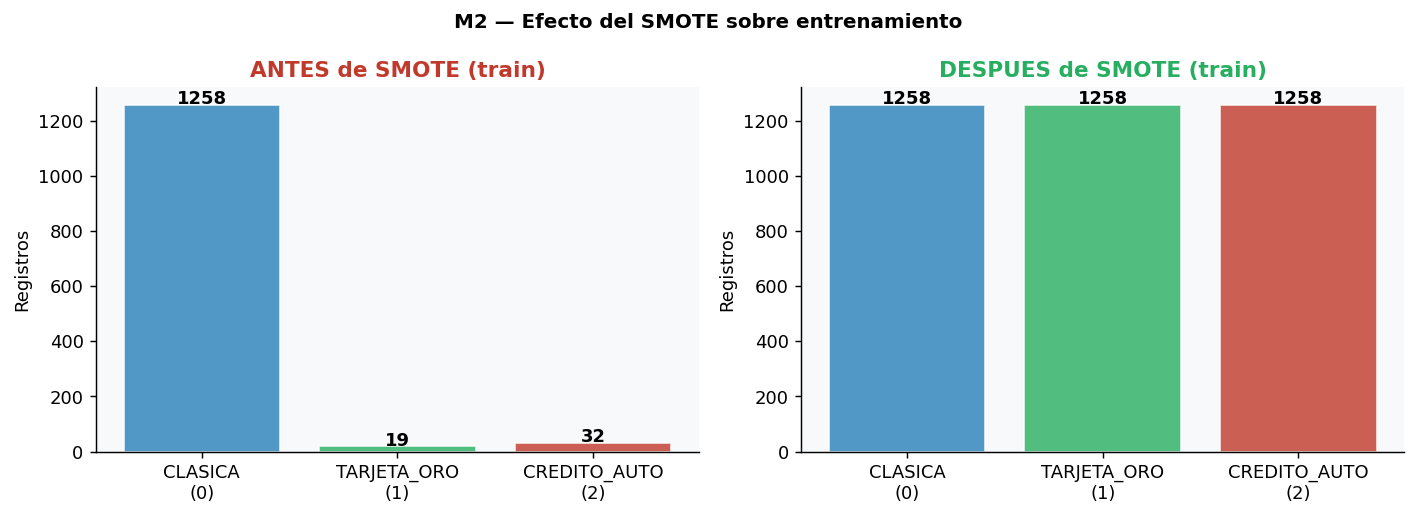

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
nombres_c = [f"CLASICA\n(0)", f"TARJETA_ORO\n(1)", f"CREDITO_AUTO\n(2)"]
colores_c = [BLUE, GREEN, RED]

vc_a = y_train_m2.value_counts().sort_index()
axes[0].bar(nombres_c, vc_a.values, color=colores_c, alpha=0.8, edgecolor="white")
axes[0].set_title("ANTES de SMOTE (train)", fontweight="bold", color=RED)
axes[0].set_ylabel("Registros")
for i, v in enumerate(vc_a.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")

vc_d = pd.Series(y_train_m2_sm).value_counts().sort_index()
axes[1].bar(nombres_c, vc_d.values, color=colores_c, alpha=0.8, edgecolor="white")
axes[1].set_title("DESPUES de SMOTE (train)", fontweight="bold", color=GREEN)
axes[1].set_ylabel("Registros")
for i, v in enumerate(vc_d.values):
    axes[1].text(i, v + 3, str(v), ha="center", fontweight="bold")

plt.suptitle("M2 — Efecto del SMOTE sobre entrenamiento",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/04_smote_m2.png", bbox_inches="tight")
plt.show()


## M2.2 · Random Forest

=== M2 — Random Forest ===



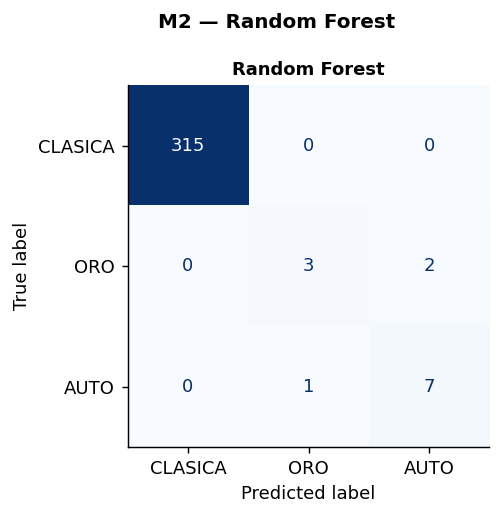

    ■  Accuracy    : 0.9909
    ■  Precision   : 0.8426
    ■  Recall      : 0.8250
    ■  F1_macro    : 0.8301
    ■  ROC_AUC     : 0.9980
    ■  Kappa       : 0.8810

              precision    recall  f1-score   support

     CLASICA       1.00      1.00      1.00       315
 TARJETA_ORO       0.75      0.60      0.67         5
CREDITO_AUTO       0.78      0.88      0.82         8

    accuracy                           0.99       328
   macro avg       0.84      0.83      0.83       328
weighted avg       0.99      0.99      0.99       328



In [14]:
print("=== M2 — Random Forest ===")
print()

rf_m2 = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                random_state=SEED, n_jobs=-1)
rf_m2.fit(X_train_m2_sm, y_train_m2_sm)

fig, ax = plt.subplots(figsize=(5, 4))
res_rf_m2 = evaluar_modelo("Random Forest", rf_m2, X_test_m2, y_test_m2,
                            multi=True, ax_cm=ax)
ax.set_xticklabels(["CLASICA","ORO","AUTO"])
ax.set_yticklabels(["CLASICA","ORO","AUTO"])
plt.suptitle("M2 — Random Forest", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/04_cm_m2_rf.png", bbox_inches="tight")
plt.show()

imprimir_metricas(res_rf_m2)
print()
print(classification_report(y_test_m2, rf_m2.predict(X_test_m2),
                             target_names=["CLASICA","TARJETA_ORO","CREDITO_AUTO"],
                             zero_division=0))


## M2.3 · Gradient Boosting

=== M2 — Gradient Boosting ===



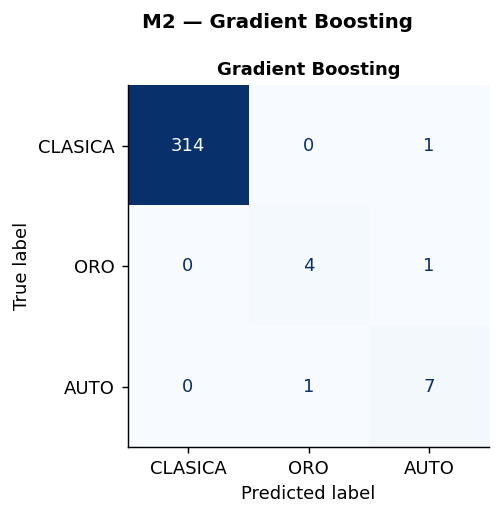

    ■  Accuracy    : 0.9909
    ■  Precision   : 0.8593
    ■  Recall      : 0.8906
    ■  F1_macro    : 0.8740
    ■  ROC_AUC     : 0.9972
    ■  Kappa       : 0.8853

              precision    recall  f1-score   support

     CLASICA       1.00      1.00      1.00       315
 TARJETA_ORO       0.80      0.80      0.80         5
CREDITO_AUTO       0.78      0.88      0.82         8

    accuracy                           0.99       328
   macro avg       0.86      0.89      0.87       328
weighted avg       0.99      0.99      0.99       328



In [15]:
print("=== M2 — Gradient Boosting ===")
print()

gb_m2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                     max_depth=4, random_state=SEED)
gb_m2.fit(X_train_m2_sm, y_train_m2_sm)

fig, ax = plt.subplots(figsize=(5, 4))
res_gb_m2 = evaluar_modelo("Gradient Boosting", gb_m2, X_test_m2, y_test_m2,
                            multi=True, ax_cm=ax)
ax.set_xticklabels(["CLASICA","ORO","AUTO"])
ax.set_yticklabels(["CLASICA","ORO","AUTO"])
plt.suptitle("M2 — Gradient Boosting", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/04_cm_m2_gb.png", bbox_inches="tight")
plt.show()

imprimir_metricas(res_gb_m2)
print()
print(classification_report(y_test_m2, gb_m2.predict(X_test_m2),
                             target_names=["CLASICA","TARJETA_ORO","CREDITO_AUTO"],
                             zero_division=0))


## M2.4 · Comparación y selección

In [16]:
resultados_m2 = pd.DataFrame([res_rf_m2, res_gb_m2]).set_index("Modelo")

print("=== COMPARACION M2 — Producto ===")
print()
print(resultados_m2.to_string())
print()

mejor_m2_nombre = resultados_m2["F1_macro"].idxmax()
mejor_m2 = {"Random Forest": rf_m2, "Gradient Boosting": gb_m2}[mejor_m2_nombre]

print(f"  {SQ_G}  Mejor modelo : {mejor_m2_nombre}")
print(f"  {SQ_G}  F1 macro     : {resultados_m2.loc[mejor_m2_nombre,'F1_macro']:.4f}")
print(f"  {SQ_G}  Kappa        : {resultados_m2.loc[mejor_m2_nombre,'Kappa']:.4f}")
print()
print(f"  {SQ_Y}  Limitacion conocida: ORO (24 registros) y AUTO (40) tienen muy")
print(f"  {SQ_Y}  pocas muestras reales. F1 macro refleja ese techo estadistico.")
print(f"  {SQ_Y}  En un banco real se necesitaria mas historico de estos productos.")


=== COMPARACION M2 — Producto ===

                   Accuracy  Precision  Recall  F1_macro  ROC_AUC   Kappa
Modelo                                                                   
Random Forest        0.9909     0.8426  0.8250    0.8301   0.9980  0.8810
Gradient Boosting    0.9909     0.8593  0.8906    0.8740   0.9972  0.8853

  ■  Mejor modelo : Gradient Boosting
  ■  F1 macro     : 0.8740
  ■  Kappa        : 0.8853

  ■  Limitacion conocida: ORO (24 registros) y AUTO (40) tienen muy
  ■  pocas muestras reales. F1 macro refleja ese techo estadistico.
  ■  En un banco real se necesitaria mas historico de estos productos.


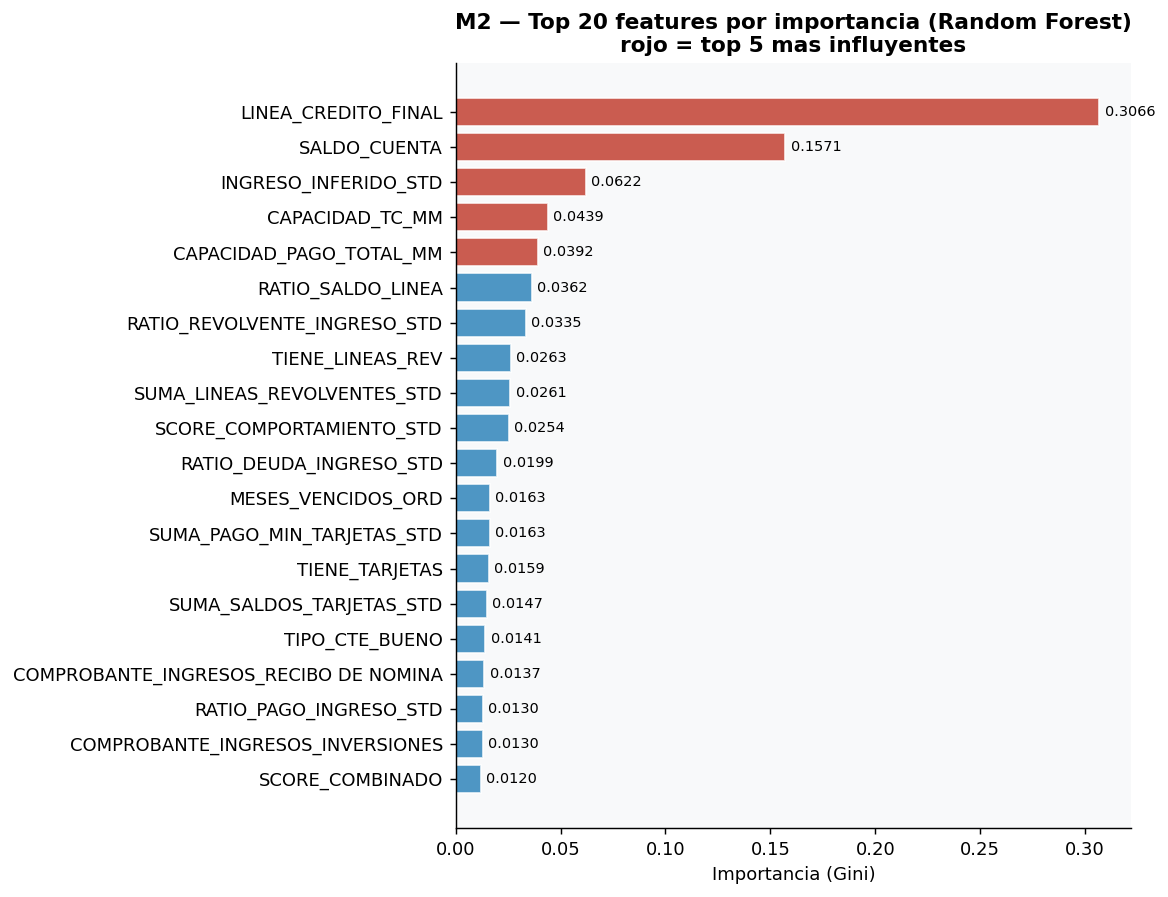

Top 10 features M2:
  LINEA_CREDITO_FINAL                        0.3066  ████████████████████████████████████████████████████████████████████████████
  SALDO_CUENTA                               0.1571  ███████████████████████████████████████
  INGRESO_INFERIDO_STD                       0.0622  ███████████████
  CAPACIDAD_TC_MM                            0.0439  ██████████
  CAPACIDAD_PAGO_TOTAL_MM                    0.0392  █████████
  RATIO_SALDO_LINEA                          0.0362  █████████
  RATIO_REVOLVENTE_INGRESO_STD               0.0335  ████████
  TIENE_LINEAS_REV                           0.0263  ██████
  SUMA_LINEAS_REVOLVENTES_STD                0.0261  ██████
  SCORE_COMPORTAMIENTO_STD                   0.0254  ██████


In [17]:
imp_m2 = pd.Series(rf_m2.feature_importances_, index=FEATURES_M2)
imp_m2 = imp_m2.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [RED if i < 5 else BLUE for i in range(len(imp_m2))]
bars = ax.barh(imp_m2.index[::-1], imp_m2.values[::-1],
               color=colors[::-1], alpha=0.82, edgecolor="white")
ax.bar_label(bars, labels=[f"{v:.4f}" for v in imp_m2.values[::-1]],
             padding=3, fontsize=8)
ax.set_title("M2 — Top 20 features por importancia (Random Forest)\n"
             "rojo = top 5 mas influyentes", fontweight="bold")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.savefig("../reports/figures/04_feature_importance_m2.png", bbox_inches="tight")
plt.show()

print("Top 10 features M2:")
for feat, imp in imp_m2.head(10).items():
    bar = chr(9608) * int(imp * 250)
    print(f"  {feat:<42} {imp:.4f}  {bar}")


---
# Resumen de resultados

In [20]:
print("=" * 62)
print("  RESUMEN FINAL DE MODELOS")
print("=" * 62)
print()
print("  M1 — Aprobacion:")
print(resultados_m1.to_string())
print()
print("  M2 — Producto:")
print(resultados_m2.to_string())
print()

mejor_m1_nombre = resultados_m1["F1_macro"].idxmax()
mejor_m2_nombre = resultados_m2["F1_macro"].idxmax()
modelo_final_m1 = {"Regresion Logistica": lr_m1,
                   "Random Forest": rf_m1,
                   "Gradient Boosting": gb_m1}[mejor_m1_nombre]
modelo_final_m2 = {"Random Forest": rf_m2,
                   "Gradient Boosting": gb_m2}[mejor_m2_nombre]

print(f"  {SQ_G}  Modelo final M1 : {mejor_m1_nombre}")
print(f"  {SQ_G}  Modelo final M2 : {mejor_m2_nombre}")
print()

# Guia Kappa
print("  Guia Kappa de Cohen:")
for rango, etq in [("0.00-0.20","Sin acuerdo"), ("0.21-0.40","Acuerdo justo"),
                   ("0.41-0.60","Acuerdo moderado"), ("0.61-0.80","Acuerdo sustancial"),
                   ("0.81-1.00","Acuerdo casi perfecto")]:
    print(f"    {rango}  {etq}")


  RESUMEN FINAL DE MODELOS

  M1 — Aprobacion:
                     Accuracy  Precision  Recall  F1_macro  ROC_AUC   Kappa
Modelo                                                                     
Regresion Logistica    0.9954        1.0  0.9878    0.9938      1.0  0.9902
Random Forest          1.0000        1.0  1.0000    1.0000      1.0  1.0000
Gradient Boosting      1.0000        1.0  1.0000    1.0000      1.0  1.0000

  M2 — Producto:
                   Accuracy  Precision  Recall  F1_macro  ROC_AUC   Kappa
Modelo                                                                   
Random Forest        0.9909     0.8426  0.8250    0.8301   0.9980  0.8810
Gradient Boosting    0.9909     0.8593  0.8906    0.8740   0.9972  0.8853

  ■  Modelo final M1 : Random Forest
  ■  Modelo final M2 : Gradient Boosting

  Guia Kappa de Cohen:
    0.00-0.20  Sin acuerdo
    0.21-0.40  Acuerdo justo
    0.41-0.60  Acuerdo moderado
    0.61-0.80  Acuerdo sustancial
    0.81-1.00  Acuerdo casi perfec

---
## CSVs con predicciones

In [21]:
print("=== Guardando CSVs con predicciones ===")
print()

mapa_inv = {0:"CLASICA", 1:"TARJETA_ORO", 2:"CREDITO_AUTO"}

# ── M1: predicciones de aprobacion ───────────────────────────────────────────
df_m1_out = df_m1.copy()
X_full_m1 = df_m1[FEATURES_M1_LR] if mejor_m1_nombre == "Regresion Logistica" else X_m1
df_m1_out["PRED_APROBADO"]    = modelo_final_m1.predict(X_full_m1)
df_m1_out["PROB_APROBADO"]    = modelo_final_m1.predict_proba(X_full_m1)[:, 1].round(4)
df_m1_out["PRED_CORRECTA_M1"] = (df_m1_out["PRED_APROBADO"] == df_m1_out["TARGET_APROBADO"]).astype(int)

df_m1_out.to_csv("../data/processed/predicciones_aprobacion.csv", index=False, encoding="utf-8")
acc_m1 = df_m1_out["PRED_CORRECTA_M1"].mean()
print(f"  {SQ_G}  predicciones_aprobacion.csv   shape: {df_m1_out.shape}  accuracy: {acc_m1:.4f}")

# ── M2: predicciones de producto ──────────────────────────────────────────────
df_m2_out = df_m2.copy()
probs_m2 = modelo_final_m2.predict_proba(X_m2)
df_m2_out["PRED_PRODUCTO"]        = modelo_final_m2.predict(X_m2)
df_m2_out["PRED_PRODUCTO_NOMBRE"] = df_m2_out["PRED_PRODUCTO"].map(mapa_inv)
df_m2_out["PROB_CLASICA"]         = probs_m2[:, 0].round(4)
df_m2_out["PROB_ORO"]             = probs_m2[:, 1].round(4)
df_m2_out["PROB_AUTO"]            = probs_m2[:, 2].round(4)
df_m2_out["PRED_CORRECTA_M2"]     = (df_m2_out["PRED_PRODUCTO"] == df_m2_out["TARGET_PRODUCTO"]).astype(int)

df_m2_out.to_csv("../data/processed/predicciones_producto.csv", index=False, encoding="utf-8")
acc_m2 = df_m2_out["PRED_CORRECTA_M2"].mean()
print(f"  {SQ_G}  predicciones_producto.csv     shape: {df_m2_out.shape}  accuracy: {acc_m2:.4f}")
print()
print("  Predicciones M2 por producto (dataset completo):")
for v, c in df_m2_out["PRED_PRODUCTO_NOMBRE"].value_counts().items():
    pct = c / len(df_m2_out) * 100
    print(f"    {str(v):<14}  {c:>5,}  ({pct:.1f}%)")


=== Guardando CSVs con predicciones ===

  ■  predicciones_aprobacion.csv   shape: (4349, 36)  accuracy: 1.0000
  ■  predicciones_producto.csv     shape: (1637, 46)  accuracy: 0.9982

  Predicciones M2 por producto (dataset completo):
    CLASICA         1,572  (96.0%)
    CREDITO_AUTO       41  (2.5%)
    TARJETA_ORO        24  (1.5%)


---
## Guardar modelos 

In [22]:
import joblib

joblib.dump(modelo_final_m1,
    f"../models/modelo_aprobacion.pkl")
joblib.dump(modelo_final_m2,
    f"../models/modelo_producto.pkl")

print("Modelos guardados.")

Modelos guardados.


---
## Tabla de referencia — Interpretación de métricas

| Métrica | Qué mide | Cuándo priorizarla |
|---|---|---|
| **Accuracy** | % de predicciones correctas totales | Solo cuando las clases están balanceadas |
| **Precision** | De los que predije como aprobados, ¿cuántos lo son realmente? | Cuando el costo de falso positivo es alto |
| **Recall** | De los aprobados reales, ¿cuántos encontré? | Cuando el costo de falso negativo es alto |
| **F1 macro** | Media armónica precision-recall, promediada por clase | Con desbalance — nuestra métrica principal |
| **ROC-AUC** | Capacidad de discriminar entre clases | Evaluación general del ranking |
| **Kappa de Cohen** | Acuerdo real vs predicción aleatoria | Confirma que el modelo aprende algo real |

### Por qué la Kappa importa con desbalance

Con 62% de clase mayoritaria en M1, un modelo que prediga siempre "rechazado"  
tendría 62% de Accuracy pero **Kappa = 0** — no aprendió nada.  
Kappa > 0.6 confirma poder predictivo real más allá del azar.
